In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from mlxtend.preprocessing import TransactionEncoder
from sklearn.preprocessing import MinMaxScaler
# import import import!!!


In [ ]:
df=pd.read_csv("Smartphone.csv")
df.head()
# อ่านข้อมูล

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [ ]:
df.value_counts('gender')
# นับว่ามี gender อะไรบ้างและมากแค่ไหน

gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64

In [ ]:
# เติมข้อมูลว่างด้วย 0
df.fillna(0, inplace=True)

In [ ]:
print("Missing Values:\n", df.isnull().sum())
# ดูว่าเหลือมั้ย


Missing Values:
 transaction_id             0
user_id                    0
age                        0
gender                     0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
addiction_level            0
addicted_label             0
dtype: int64


C:\Users\Smart\AppData\Local\Temp\ipykernel_12900\1576620330.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='Set2')


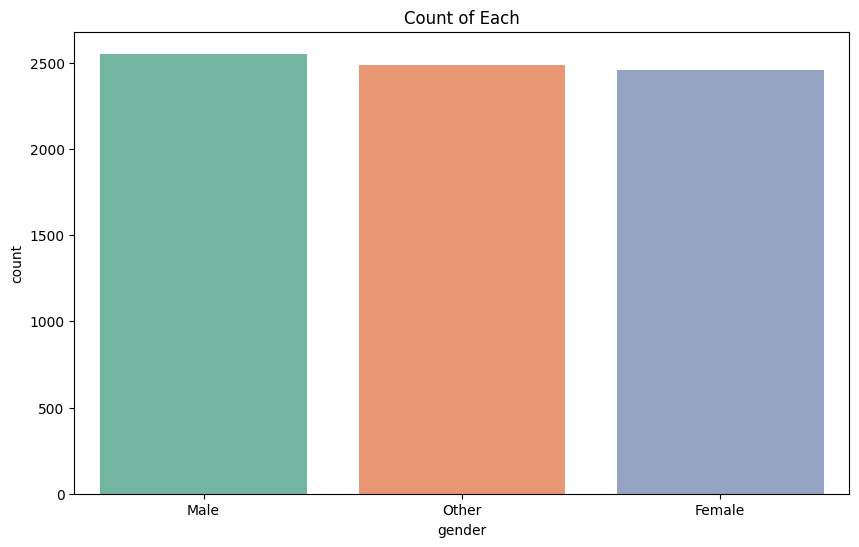

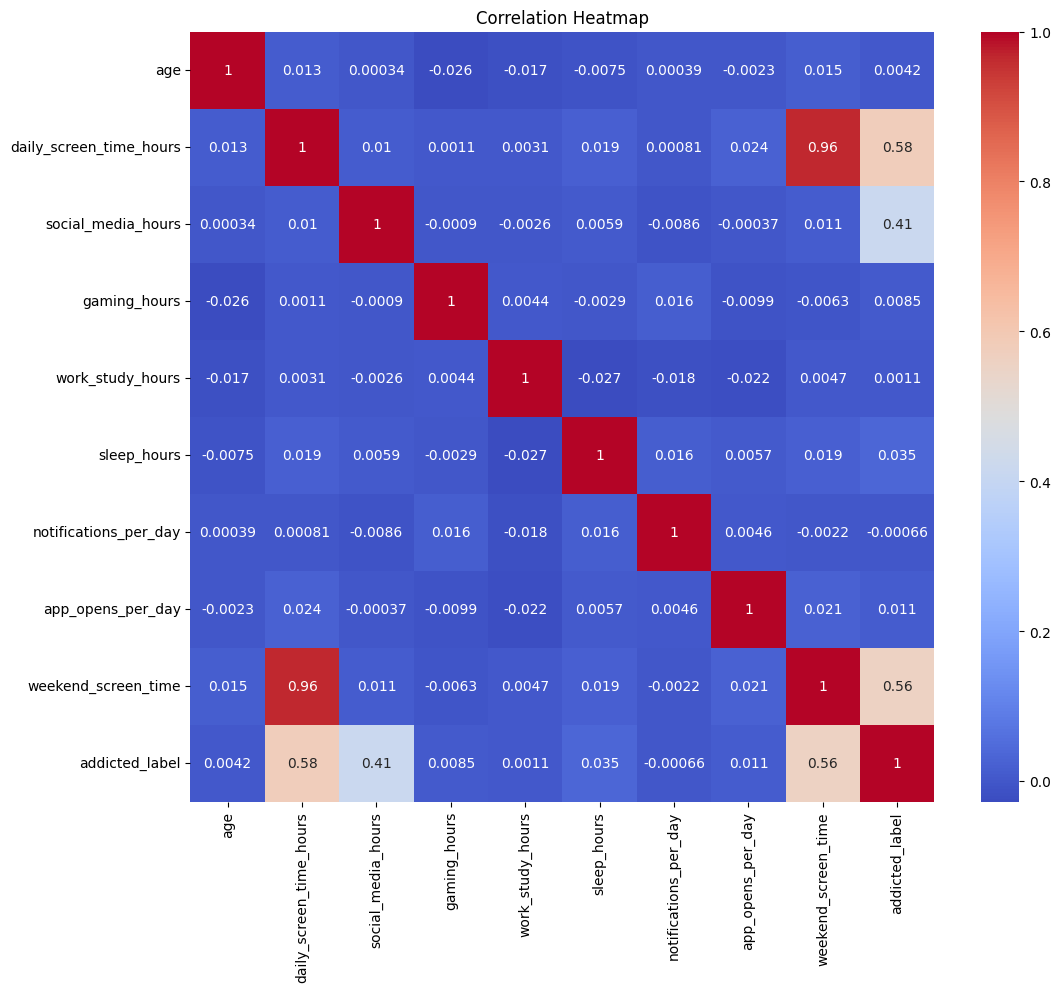

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='gender', data=df, palette='Set2') #ทำตารางดู gender
plt.title("Count of Each")
plt.show()

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm') #ตารางความสัมพันธ์กับทุกตัวแปร
plt.title("Correlation Heatmap")
plt.show()

In [35]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,0,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,0,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [ ]:
df.replace({'gender':{'Male':0,'Female':1,'Other':2}},inplace=True)
df.replace({'stress_level':{'Low':0,'Medium':1,'High':2}},inplace=True)
df.replace({'academic_work_impact':{'No':0,'Yes':1}},inplace=True)
df.replace({'addiction_level':{'Mild':0,'Moderate':1,'Severe':2}},inplace=True)
df = df.drop(columns=['transaction_id', 'user_id'])
#แปลงข้อมูลตัวอักษรเป็นตัวเลข
df.head(5)


C:\Users\Smart\AppData\Local\Temp\ipykernel_12900\758502783.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'gender':{'Male':0,'Female':1,'Other':2}},inplace=True)
C:\Users\Smart\AppData\Local\Temp\ipykernel_12900\758502783.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'stress_level':{'Low':0,'Medium':1,'High':2}},inplace=True)
C:\Users\Smart\AppData\Local\Temp\ipykernel_12900\758502783.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,21,0,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,1,0,0
1,24,2,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,1,0,0
2,31,2,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,0,0,0
3,32,2,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,1,1,1
4,25,0,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,0,2,1


✅ KNN Model Trained! (k=41)
📊 สัดส่วนข้อมูลทั้งหมด: ผ่าน 2,000 | ไม่ผ่าน 2,000


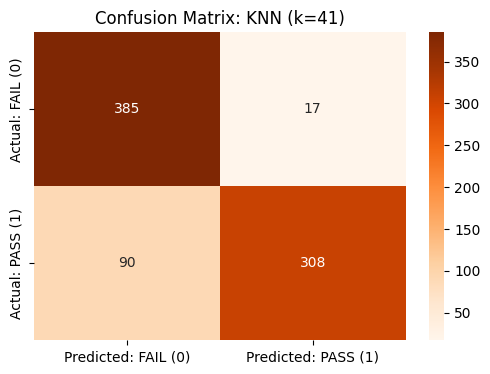

🏆 Accuracy Score: 0.8662
              precision    recall  f1-score   support

           0       0.81      0.96      0.88       402
           1       0.95      0.77      0.85       398

    accuracy                           0.87       800
   macro avg       0.88      0.87      0.86       800
weighted avg       0.88      0.87      0.87       800



In [ ]:


df_pass = df[df['addicted_label'] == 1]
df_fail = df[df['addicted_label'] == 0]

# สุ่มฝั่งละ 2000 รวมเป็น 4000 แถว
n_samples = 2000 
df_pass_sampled = df_pass.sample(n=min(n_samples, len(df_pass)), random_state=42)
df_fail_sampled = df_fail.sample(n=min(n_samples, len(df_fail)), random_state=42)

df_main = pd.concat([df_pass_sampled, df_fail_sampled]).sample(frac=1, random_state=42)
df_main.columns = df_main.columns.str.strip()

X = df_main.drop(columns=['addicted_label','addiction_level']) # ไม่เอา
y = df_main['addicted_label']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 2. เทรนโมเดล KNN (k=30) และ Confusion Matrix
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# เปลี่ยน k ตามใจ (k เป็น 41 เพราะทำการหาค่า k ที่ดีที่สุดจากโค้ดต่อไป)
k_val = 41
model = KNeighborsClassifier(n_neighbors=k_val)
model.fit(X_train, y_train)

print(f"✅ KNN Model Trained! (k={k_val})")
print(f"📊 สัดส่วนข้อมูลทั้งหมด: ผ่าน {sum(y==1):,} | ไม่ผ่าน {sum(y==0):,}")

# สร้าง Confusion Matrix
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted: FAIL (0)', 'Predicted: PASS (1)'],
            yticklabels=['Actual: FAIL (0)', 'Actual: PASS (1)'])
plt.title(f'Confusion Matrix: KNN (k={k_val})')
plt.show()

print(f"🏆 Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))


In [ ]:
correlations = df_main.corr()['addicted_label'].sort_values(ascending=False) #ความเกี่ยวเนี่องกัน addiction_level เกี่ยวข้องเกินไป test ข้อมูลไม่ได้เลยเอาออก
print(correlations)

addicted_label             1.000000
addiction_level            0.901658
daily_screen_time_hours    0.652266
weekend_screen_time        0.627924
social_media_hours         0.471909
sleep_hours                0.055154
app_opens_per_day          0.010300
gaming_hours               0.008055
academic_work_impact       0.007500
work_study_hours          -0.003291
notifications_per_day     -0.003654
age                       -0.005087
gender                    -0.027077
stress_level              -0.040527
Name: addicted_label, dtype: float64


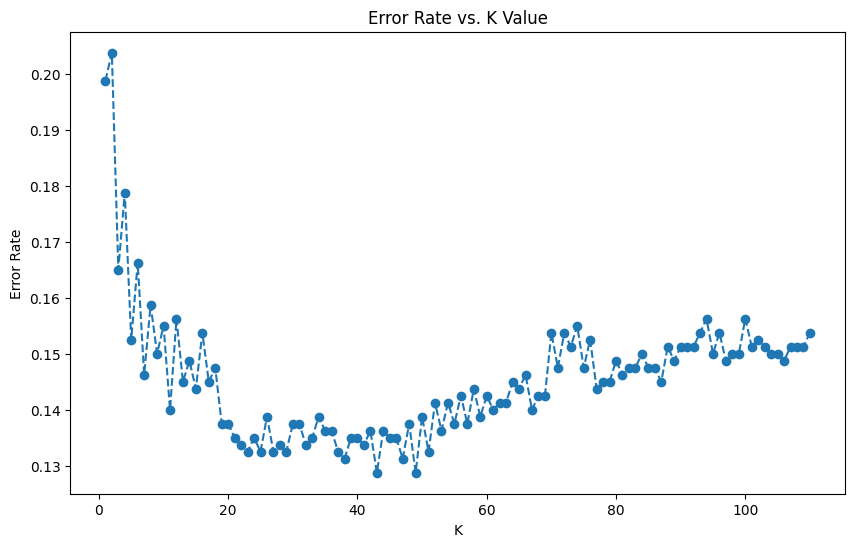

In [ ]:
error_rate = []
for i in range(1, 111): #ลอง k=1 - 111 หา error น้อยที่สุด
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,111), error_rate, marker='o', linestyle='--')
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()